# Disaster Recovery Cost Prediction and Resilience Optimization
## Week 1 Day 4 — Exploratory Data Analysis

## Section A — Imports and setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/raw")

## Section B — Load the 3 raw datasets

In [3]:
df_decl = pd.read_csv(DATA_DIR / "disaster_declarations_summaries.csv")
df_pa = pd.read_csv(DATA_DIR / "public_assistance_funded_projects_details.csv")
df_sum = pd.read_csv(DATA_DIR / "fema_web_disaster_summaries.csv")

print("Declarations:", df_decl.shape)
print("Public Assistance:", df_pa.shape)
print("Disaster Summaries:", df_sum.shape)

Declarations: (69770, 28)
Public Assistance: (810787, 25)
Disaster Summaries: (3909, 14)


In [4]:
display(df_decl.head())
display(df_pa.head())
display(df_sum.head())

,femaDeclarationString,disasterNumber,state,declarationType,declarationDate,fyDeclared,incidentType,declarationTitle,ihProgramDeclared,iaProgramDeclared,paProgramDeclared,hmProgramDeclared,incidentBeginDate,incidentEndDate,disasterCloseoutDate,tribalRequest,fipsStateCode,fipsCountyCode,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash,id
0,FM-5529-OR,5529,OR,FM,2024-08-09T00:00:00.000Z,2024,Fire,LEE FALLS FIRE,False,False,True,True,2024-08-08T00:00:00.000Z,NaN,NaN,False,41,67,99067,Washington (County),24122,NaN,2024081001,10,R,2024-08-27T18:22:14.800Z,ae87cf3c6ed795015b714af7166c7c295b2b67c7,09e3f81a-5e16-4b72-b317-1c64e0cfa59c
1,FM-5528-OR,5528,OR,FM,2024-08-06T00:00:00.000Z,2024,Fire,ELK LANE FIRE,False,False,True,True,2024-08-04T00:00:00.000Z,NaN,NaN,False,41,31,99031,Jefferson (County),24116,NaN,2024080701,10,R,2024-08-27T18:22:14.800Z,432cf0995c47e3895cea696ede5621b810460501,59983f89-30bf-4888-b21b-62e8d57d9aac
2,FM-5527-OR,5527,OR,FM,2024-08-02T00:00:00.000Z,2024,Fire,MILE MARKER 132 FIRE,False,False,True,True,2024-08-02T00:00:00.000Z,NaN,NaN,False,41,17,99017,Deschutes (County),24111,NaN,2024080301,10,R,2024-08-27T18:22:14.800Z,2f21d90cb6bc64b0d4121aa3f18d852bbb4b11fa,8d13ecf0-bc2f-496b-8c9f-b2e73da832a0
3,DR-4312-CA,4312,CA,DR,2017-05-02T00:00:00.000Z,2017,Severe Storm,FLOODING,False,False,True,True,2017-02-08T00:00:00.000Z,2017-02-11T00:00:00.000Z,2025-03-25T00:00:00.000Z,True,6,0,60347,Resighini Rancheria (Indian Reservation),17035,NaN,2017041001,9,NaN,2025-03-26T20:21:32.579Z,432a3a64bdbb291ae26cf5a27a33deeabb380481,98a7c5bb-2346-45aa-a1ca-0399440d4f0b
4,DR-4251-AL,4251,AL,DR,2016-01-21T00:00:00.000Z,2016,Severe Storm,"SEVERE STORMS, TORNADOES, STRAIGHT-LINE WINDS,...",False,False,True,True,2015-12-23T00:00:00.000Z,2015-12-31T00:00:00.000Z,2025-03-27T00:00:00.000Z,False,1,1,99001,Autauga (County),16003,NaN,2015122301,4,NaN,2025-03-27T12:21:46.559Z,dcd4ce6b37ee49875b3f1e32e9a8a16cd6a803d3,5229bbae-eee6-42b8-b277-edbafa8d6cb2


,disasterNumber,declarationDate,incidentType,pwNumber,applicationTitle,applicantId,damageCategoryCode,damageCategoryDescrip,projectStatus,projectProcessStep,projectSize,county,countyCode,stateAbbreviation,stateNumberCode,projectAmount,federalShareObligated,totalObligated,lastObligationDate,firstObligationDate,mitigationAmount,gmProjectId,gmApplicantId,lastRefresh,hash
0,1239,1998-08-26T00:00:00.000Z,Severe Storm(s),1,(PW# 1) IMMEDIATE NEEDS FUNDING,465-19792-00,B,Emergency Protective Measures,Active,Project Closed Out,Large,Val Verde County,465,TX,48,100000.00,75000.00,80340.00,1998-09-15T14:25:07.000Z,1998-09-15T14:25:07.000Z,0.0,1021769,268458,2025-11-27T15:05:59.253Z,addcfded82ae348f46ff034a4564f983a9dea897
1,1239,1998-08-26T00:00:00.000Z,Severe Storm(s),5,(PW# 5) Not Provided,465-19792-00,G,"Parks, Recreational Facilities, and Other Items",Active,Project Closed Out,Large,Val Verde County,465,TX,48,19685.50,14764.13,15461.00,1998-09-23T08:58:52.000Z,1998-09-23T08:58:52.000Z,0.0,1062596,268458,2025-11-27T15:05:59.253Z,05c6c522b930a9c38b52a0c4b0de853e98b4cb75
2,1239,1998-08-26T00:00:00.000Z,Severe Storm(s),7,(PW# 7) Not Provided,465-19792-00,G,"Parks, Recreational Facilities, and Other Items",Active,Project Closed Out,Large,Val Verde County,465,TX,48,26111.00,19583.25,20507.58,1998-09-23T08:58:52.000Z,1998-09-23T08:58:52.000Z,0.0,1062598,268458,2025-11-27T15:05:59.253Z,0addbfed02721821348612482bfe36d8fe587d0f
3,1239,1998-08-26T00:00:00.000Z,Severe Storm(s),8,(PW# 8) Not Provided,465-19792-00,G,"Parks, Recreational Facilities, and Other Items",Active,Project Closed Out,Large,Val Verde County,465,TX,48,26250.83,19688.12,20617.40,1998-09-28T15:02:18.000Z,1998-09-28T15:02:18.000Z,0.0,1062599,268458,2025-11-27T15:05:59.253Z,d01abd86d6129cc818c5cee0f9373e3097c245e6
4,1239,1998-08-26T00:00:00.000Z,Severe Storm(s),10,(PW# 10) Not Provided,465-19792-00,G,"Parks, Recreational Facilities, and Other Items",Active,Project Closed Out,Large,Val Verde County,465,TX,48,34502.50,25876.88,27098.27,1998-09-28T15:02:18.000Z,1998-09-28T15:02:18.000Z,0.0,1062578,268458,2025-11-27T15:05:59.253Z,ae1b100b0fe6a9fd0a75c120e0ca3a5e4be6d356


,disasterNumber,totalNumberIaApproved,totalAmountIhpApproved,totalAmountHaApproved,totalAmountOnaApproved,totalObligatedAmountPa,totalObligatedAmountCatAb,totalObligatedAmountCatC2g,paLoadDate,iaLoadDate,totalObligatedAmountHmgp,hash,lastRefresh,id
0,3601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3de68baba960e69da445cf822d3dd859081fb34a,2023-10-09T23:02:26.341Z,faafecca-0f76-4fb8-8ffd-b6f46f3b712c
1,3602,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58566c446fce5cabbd0c3412a6bb3daa4ada1993,2023-10-09T23:02:26.341Z,b74f0dc2-fab5-42b9-acf7-c94df14d85ad
2,1981,7469.0,95754618.67,93631947.01,2122671.66,2.243558e+08,94967791.86,1.197739e+08,2026-02-06T00:00:00.000Z,2026-04-05T00:00:00.000Z,71549737.00,24cc4ca4c5602ae7f9ed7a94ff2ad08b28789674,2026-04-05T06:02:19.627Z,ecb4804b-cfde-4437-93b5-1334c1815fee
3,1802,NaN,NaN,NaN,NaN,1.881275e+07,13423088.38,4.869890e+06,2026-02-06T00:00:00.000Z,NaN,2710679.00,d5b8865b047c2db34bae425a847682fc5c952d47,2026-02-06T02:02:06.586Z,b3ae5013-d6cc-46f3-a692-18191be44083
4,4317,1978.0,12527583.31,10311780.12,2215803.19,7.731984e+07,11526563.99,6.437977e+07,2026-04-05T00:00:00.000Z,2026-04-05T00:00:00.000Z,17801245.73,a37f2cacbd2f2184de5465c2148b1a228e4be246,2026-04-05T06:02:19.627Z,c3af2a42-752e-427c-a9ae-6b6cefa31b22


## Section D — Data quality report function

In [5]:
def data_quality_report(df: pd.DataFrame, name: str) -> pd.DataFrame:
    report = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "null_count": df.isnull().sum().values,
        "null_rate_pct": (df.isnull().mean() * 100).round(2).values,
        "n_unique": [df[col].nunique(dropna=True) for col in df.columns]
    })
    report["dataset"] = name
    report = report[["dataset", "column", "dtype", "null_count", "null_rate_pct", "n_unique"]]
    return report

## Section E — Run data quality checks

In [9]:
quality_decl = data_quality_report(df_decl, "disaster_declarations")
quality_pa = data_quality_report(df_pa, "public_assistance")
quality_sum = data_quality_report(df_sum, "fema_web_disaster_summaries")

print("Duplicate rows in declarations:", df_decl.duplicated().sum())
print("Duplicate rows in public assistance:", df_pa.duplicated().sum())
print("Duplicate rows in summaries:", df_sum.duplicated().sum())

display(quality_decl)


Duplicate rows in declarations: 0
Duplicate rows in public assistance: 0
Duplicate rows in summaries: 0


,dataset,column,dtype,null_count,null_rate_pct,n_unique
0,disaster_declarations,femaDeclarationString,object,0,0.00,5163
1,disaster_declarations,disasterNumber,int64,0,0.00,5163
2,disaster_declarations,state,object,0,0.00,59
3,disaster_declarations,declarationType,object,0,0.00,3
4,disaster_declarations,declarationDate,"datetime64[ns, UTC]",0,0.00,3585
5,disaster_declarations,fyDeclared,int64,0,0.00,74
6,disaster_declarations,incidentType,object,0,0.00,27
7,disaster_declarations,declarationTitle,object,0,0.00,2475
8,disaster_declarations,ihProgramDeclared,bool,0,0.00,2
9,disaster_declarations,iaProgramDeclared,bool,0,0.00,2


In [10]:
display(quality_pa)


,dataset,column,dtype,null_count,null_rate_pct,n_unique
0,public_assistance,disasterNumber,int64,0,0.00,1766
1,public_assistance,declarationDate,object,0,0.00,1308
2,public_assistance,incidentType,object,0,0.00,26
3,public_assistance,pwNumber,int64,0,0.00,18547
4,public_assistance,applicationTitle,object,0,0.00,646471
5,public_assistance,applicantId,object,5,0.00,66614
6,public_assistance,damageCategoryCode,object,0,0.00,9
7,public_assistance,damageCategoryDescrip,object,0,0.00,12
8,public_assistance,projectStatus,object,0,0.00,4
9,public_assistance,projectProcessStep,object,0,0.00,40


In [11]:
display(quality_sum)

,dataset,column,dtype,null_count,null_rate_pct,n_unique
0,fema_web_disaster_summaries,disasterNumber,int64,0,0.00,3909
1,fema_web_disaster_summaries,totalNumberIaApproved,float64,3308,84.63,578
2,fema_web_disaster_summaries,totalAmountIhpApproved,float64,3308,84.63,601
3,fema_web_disaster_summaries,totalAmountHaApproved,float64,3364,86.06,545
4,fema_web_disaster_summaries,totalAmountOnaApproved,float64,3310,84.68,599
5,fema_web_disaster_summaries,totalObligatedAmountPa,float64,924,23.64,2974
6,fema_web_disaster_summaries,totalObligatedAmountCatAb,float64,1185,30.31,2709
7,fema_web_disaster_summaries,totalObligatedAmountCatC2g,float64,2361,60.40,1541
8,fema_web_disaster_summaries,paLoadDate,object,924,23.64,2
9,fema_web_disaster_summaries,iaLoadDate,object,3308,84.63,1


## Data Quality Findings

This section checks the shape, data types, null counts, and duplicate rows of each dataset. The purpose is to identify structural issues before deeper analysis. Any columns with high null rates or suspicious data types should be noted for cleaning in the next stage.

## Section F — Prepare modelling table

In [14]:
# Convert declaration date columns to datetime format for time-based analysis
date_cols_decl = ["declarationDate", "incidentBeginDate", "incidentEndDate"]

for col in date_cols_decl:
    if col in df_decl.columns:
        df_decl[col] = pd.to_datetime(df_decl[col], errors="coerce")

In [15]:
# Check available columns in Public Assistance dataset
print("Public Assistance columns:")
print(df_pa.columns.tolist())

Public Assistance columns:
['disasterNumber', 'declarationDate', 'incidentType', 'pwNumber', 'applicationTitle', 'applicantId', 'damageCategoryCode', 'damageCategoryDescrip', 'projectStatus', 'projectProcessStep', 'projectSize', 'county', 'countyCode', 'stateAbbreviation', 'stateNumberCode', 'projectAmount', 'federalShareObligated', 'totalObligated', 'lastObligationDate', 'firstObligationDate', 'mitigationAmount', 'gmProjectId', 'gmApplicantId', 'lastRefresh', 'hash']


In [16]:
# Convert totalObligated to numeric in case it was loaded as object/string
df_pa["totalObligated"] = pd.to_numeric(df_pa["totalObligated"], errors="coerce")

In [17]:
# Aggregate project-level costs to disaster-level total cost
target_df = (
    df_pa.groupby("disasterNumber", as_index=False)["totalObligated"]
    .sum()
    .rename(columns={"totalObligated": "total_obligated_amount"})
)

print("Target table shape:", target_df.shape)
display(target_df.head())

Target table shape: (1766, 2)


,disasterNumber,total_obligated_amount
0,1239,8224551.92
1,1257,33271088.84
2,1260,9863594.04
3,1261,5735788.22
4,1262,15374967.08


In [18]:
# Merge disaster-level target back into the declarations dataset
eda_df = df_decl.merge(target_df, on="disasterNumber", how="left")

print("EDA dataset shape:", eda_df.shape)
display(eda_df.head())

EDA dataset shape: (69770, 29)


,femaDeclarationString,disasterNumber,state,declarationType,declarationDate,fyDeclared,incidentType,declarationTitle,ihProgramDeclared,iaProgramDeclared,paProgramDeclared,hmProgramDeclared,incidentBeginDate,incidentEndDate,disasterCloseoutDate,tribalRequest,fipsStateCode,fipsCountyCode,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash,id,total_obligated_amount
0,FM-5529-OR,5529,OR,FM,2024-08-09 00:00:00+00:00,2024,Fire,LEE FALLS FIRE,False,False,True,True,2024-08-08 00:00:00+00:00,NaT,NaN,False,41,67,99067,Washington (County),24122,NaN,2024081001,10,R,2024-08-27T18:22:14.800Z,ae87cf3c6ed795015b714af7166c7c295b2b67c7,09e3f81a-5e16-4b72-b317-1c64e0cfa59c,NaN
1,FM-5528-OR,5528,OR,FM,2024-08-06 00:00:00+00:00,2024,Fire,ELK LANE FIRE,False,False,True,True,2024-08-04 00:00:00+00:00,NaT,NaN,False,41,31,99031,Jefferson (County),24116,NaN,2024080701,10,R,2024-08-27T18:22:14.800Z,432cf0995c47e3895cea696ede5621b810460501,59983f89-30bf-4888-b21b-62e8d57d9aac,NaN
2,FM-5527-OR,5527,OR,FM,2024-08-02 00:00:00+00:00,2024,Fire,MILE MARKER 132 FIRE,False,False,True,True,2024-08-02 00:00:00+00:00,NaT,NaN,False,41,17,99017,Deschutes (County),24111,NaN,2024080301,10,R,2024-08-27T18:22:14.800Z,2f21d90cb6bc64b0d4121aa3f18d852bbb4b11fa,8d13ecf0-bc2f-496b-8c9f-b2e73da832a0,NaN
3,DR-4312-CA,4312,CA,DR,2017-05-02 00:00:00+00:00,2017,Severe Storm,FLOODING,False,False,True,True,2017-02-08 00:00:00+00:00,2017-02-11 00:00:00+00:00,2025-03-25T00:00:00.000Z,True,6,0,60347,Resighini Rancheria (Indian Reservation),17035,NaN,2017041001,9,NaN,2025-03-26T20:21:32.579Z,432a3a64bdbb291ae26cf5a27a33deeabb380481,98a7c5bb-2346-45aa-a1ca-0399440d4f0b,269934.77
4,DR-4251-AL,4251,AL,DR,2016-01-21 00:00:00+00:00,2016,Severe Storm,"SEVERE STORMS, TORNADOES, STRAIGHT-LINE WINDS,...",False,False,True,True,2015-12-23 00:00:00+00:00,2015-12-31 00:00:00+00:00,2025-03-27T00:00:00.000Z,False,1,1,99001,Autauga (County),16003,NaN,2015122301,4,NaN,2025-03-27T12:21:46.559Z,dcd4ce6b37ee49875b3f1e32e9a8a16cd6a803d3,5229bbae-eee6-42b8-b277-edbafa8d6cb2,36201886.01


In [19]:
# For exploratory analysis only:
# If a disaster has no matched PA cost, fill with 0 for now.
# Later, in modelling, we may decide whether to keep, filter, or handle these differently.
eda_df["total_obligated_amount"] = eda_df["total_obligated_amount"].fillna(0)

### Interpretation

The `eda_df` table is now the main disaster-level dataset for exploratory analysis.

It combines:
- disaster declaration features from the declarations dataset
- disaster-level recovery cost from aggregated public assistance obligations

This gives us the correct grain for the project, since the final model is meant to predict recovery cost per disaster event, not per individual assistance project.

## Section G — Create Helper Features

Before plotting, it helps to derive a few simple features that make the EDA more meaningful.

We will create:
- `declaration_year` → to study long-term trends
- `declaration_month` → to study seasonality
- `incident_duration_days` → to estimate whether longer incidents tend to cost more
- `census_region` → to compare disaster cost patterns across broad US regions

These are lightweight exploratory features and will help us identify which variables may be useful later in modelling.

In [20]:
# Extract time-based features from declaration date
eda_df["declaration_year"] = eda_df["declarationDate"].dt.year
eda_df["declaration_month"] = eda_df["declarationDate"].dt.month

# Compute incident duration in days
eda_df["incident_duration_days"] = (
    eda_df["incidentEndDate"] - eda_df["incidentBeginDate"]
).dt.days

In [21]:
# Map US states to Census regions for regional analysis
census_region_map = {
    # Northeast
    "CT": "Northeast", "ME": "Northeast", "MA": "Northeast", "NH": "Northeast",
    "RI": "Northeast", "VT": "Northeast", "NJ": "Northeast", "NY": "Northeast",
    "PA": "Northeast",

    # Midwest
    "IL": "Midwest", "IN": "Midwest", "MI": "Midwest", "OH": "Midwest",
    "WI": "Midwest", "IA": "Midwest", "KS": "Midwest", "MN": "Midwest",
    "MO": "Midwest", "NE": "Midwest", "ND": "Midwest", "SD": "Midwest",

    # South
    "DE": "South", "FL": "South", "GA": "South", "MD": "South",
    "NC": "South", "SC": "South", "VA": "South", "DC": "South",
    "WV": "South", "AL": "South", "KY": "South", "MS": "South",
    "TN": "South", "AR": "South", "LA": "South", "OK": "South",
    "TX": "South",

    # West
    "AZ": "West", "CO": "West", "ID": "West", "MT": "West",
    "NV": "West", "NM": "West", "UT": "West", "WY": "West",
    "AK": "West", "CA": "West", "HI": "West", "OR": "West",
    "WA": "West",

    # Territories
    "PR": "Territory", "VI": "Territory", "GU": "Territory",
    "AS": "Territory", "MP": "Territory"
}

eda_df["census_region"] = eda_df["state"].map(census_region_map).fillna("Unknown")

In [22]:
# Quick check of newly created helper columns
eda_df[[
    "disasterNumber",
    "state",
    "incidentType",
    "declarationDate",
    "declaration_year",
    "declaration_month",
    "incident_duration_days",
    "census_region",
    "total_obligated_amount"
]].head()

,disasterNumber,state,incidentType,declarationDate,declaration_year,declaration_month,incident_duration_days,census_region,total_obligated_amount
0,5529,OR,Fire,2024-08-09 00:00:00+00:00,2024,8,NaN,West,0.00
1,5528,OR,Fire,2024-08-06 00:00:00+00:00,2024,8,NaN,West,0.00
2,5527,OR,Fire,2024-08-02 00:00:00+00:00,2024,8,NaN,West,0.00
3,4312,CA,Severe Storm,2017-05-02 00:00:00+00:00,2017,5,3.0,West,269934.77
4,4251,AL,Severe Storm,2016-01-21 00:00:00+00:00,2016,1,8.0,South,36201886.01


## Section H — Target Distribution (Raw Scale)

The first question in EDA is: what does the target variable look like?

Here, we examine the distribution of `total_obligated_amount` on its original scale. This helps us assess:
- whether the target is symmetric or skewed
- whether there are many low-cost versus high-cost disasters
- whether a transformation may be needed before modelling

For disaster cost problems, it is common to see strong right-skewness because a small number of disasters can be extremely expensive.

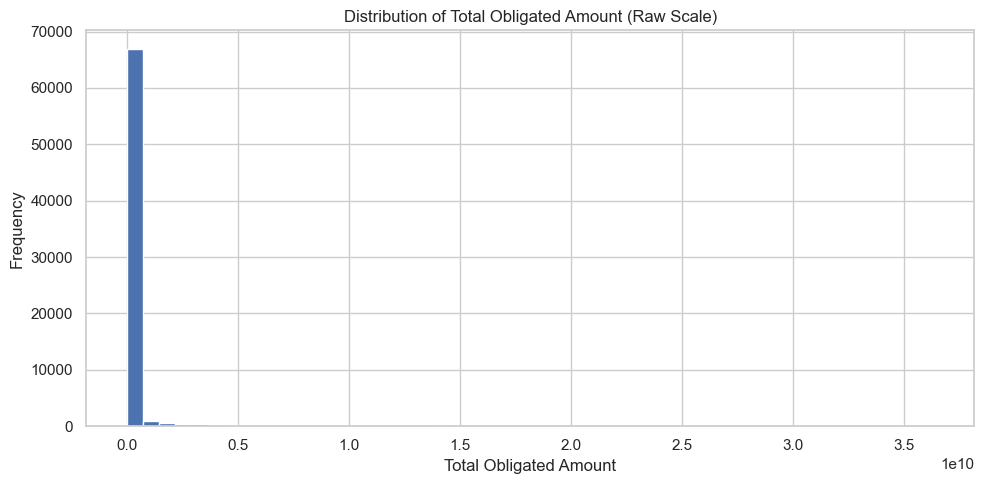

In [31]:
plt.figure(figsize=(10, 5))
plt.hist(eda_df["total_obligated_amount"], bins=50)
plt.title("Distribution of Total Obligated Amount (Raw Scale)")
plt.xlabel("Total Obligated Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Finding

The raw target distribution is likely to be heavily right-skewed. This means most disasters have relatively lower recovery costs, while a smaller number of disasters account for extremely large costs.

This is important because:
- the model may struggle if trained directly on the raw target
- a log transformation may improve stability and interpretability
- extreme values are likely to play a major role in business impact

## Section I — Target Distribution (Log Scale)

Because disaster cost data is usually highly skewed, it is helpful to apply a log transformation.

We use:

- `log_total_obligated_amount = log(1 + total_obligated_amount)`

The `+1` ensures that zero values do not cause mathematical issues.

This transformed version often gives a better view of the overall structure of the target and may later be useful in modelling.

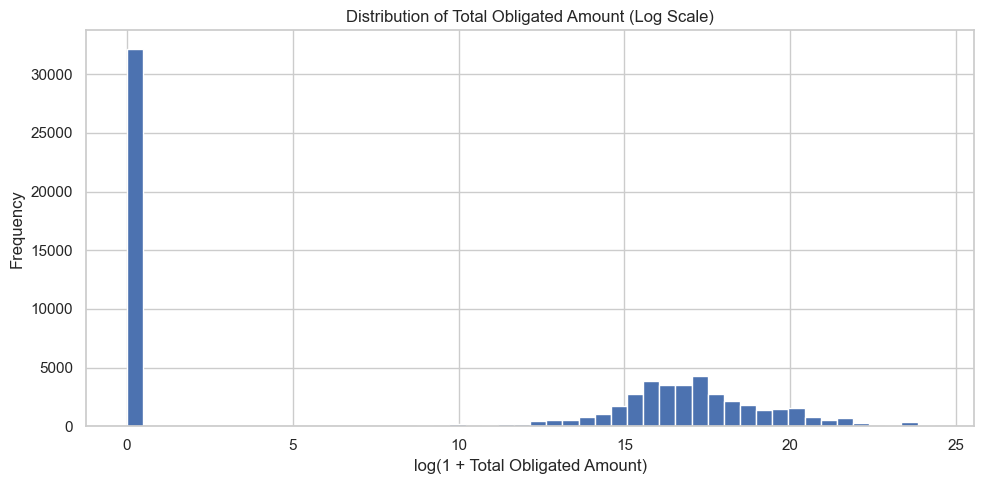

In [32]:
eda_df["log_total_obligated_amount"] = np.log1p(eda_df["total_obligated_amount"])

plt.figure(figsize=(10, 5))
plt.hist(eda_df["log_total_obligated_amount"], bins=50)
plt.title("Distribution of Total Obligated Amount (Log Scale)")
plt.xlabel("log(1 + Total Obligated Amount)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [28]:
eda_positive = eda_df[eda_df["total_obligated_amount"] > 0]

C:\Users\caspe\AppData\Local\Temp\ipykernel_10188\4044486697.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eda_positive["log_total_obligated_amount"] = np.log1p(


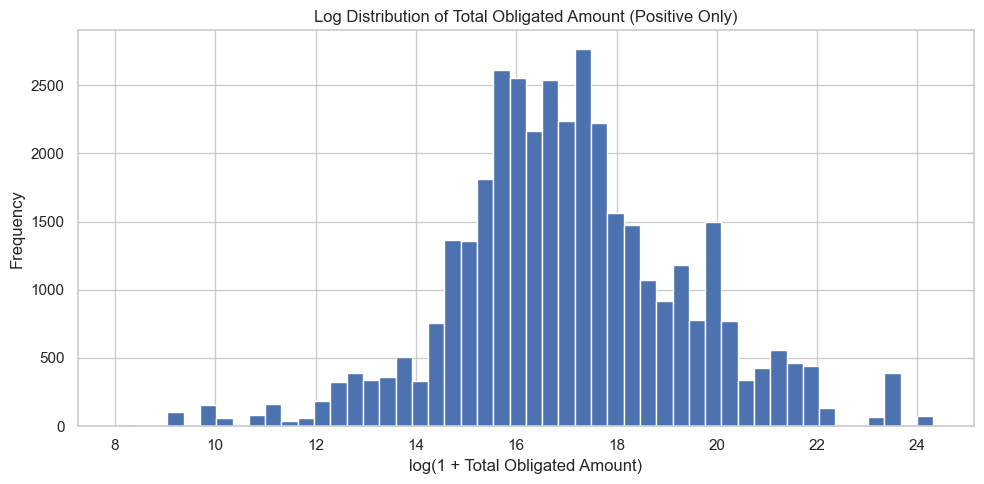

In [33]:
eda_positive["log_total_obligated_amount"] = np.log1p(
    eda_positive["total_obligated_amount"]
)

plt.figure(figsize=(10, 5))
plt.hist(eda_positive["log_total_obligated_amount"], bins=50)
plt.title("Log Distribution of Total Obligated Amount (Positive Only)")
plt.xlabel("log(1 + Total Obligated Amount)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### Finding — Log Target Distribution

The log-transformed distribution reveals a clear separation between two groups of disasters: those with zero recorded recovery cost and those with positive costs.

After filtering to include only disasters with positive cost, the distribution becomes approximately bell-shaped, indicating that the log transformation effectively normalizes the target.

This suggests:
- the dataset exhibits a zero-inflated structure, with many disasters having no recorded obligations
- modelling may require either filtering zero-cost disasters or treating them separately
- log transformation is appropriate for stabilizing variance and improving model behaviour

## Section J — Average Recovery Cost by Incident Type

Next, we examine whether different disaster categories are associated with different recovery costs.

This is important because `incidentType` is likely to be one of the strongest predictors in the final model. Some disaster types, such as hurricanes or severe storms, may systematically lead to higher recovery spending than others.

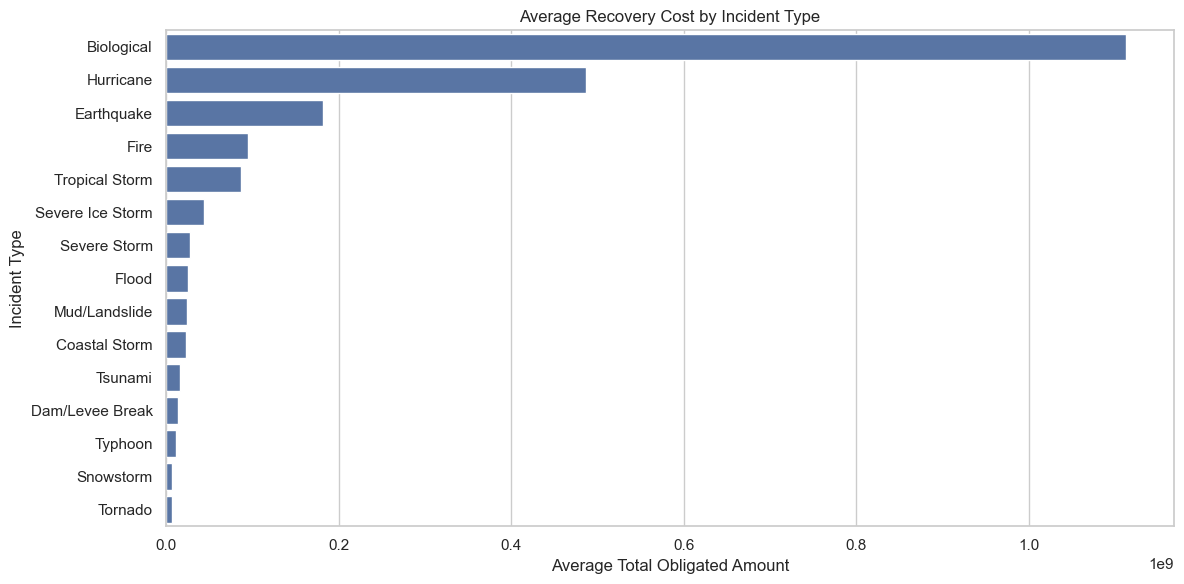

In [27]:
incident_cost = (
    eda_df.groupby("incidentType", as_index=False)["total_obligated_amount"]
    .mean()
    .sort_values("total_obligated_amount", ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))
sns.barplot(data=incident_cost, x="total_obligated_amount", y="incidentType")
plt.title("Average Recovery Cost by Incident Type")
plt.xlabel("Average Total Obligated Amount")
plt.ylabel("Incident Type")
plt.tight_layout()
plt.show()

### Finding — Cost by Incident Type

There is substantial variation in average recovery cost across incident types.

Biological disasters show the highest average cost by a significant margin, followed by hurricanes and earthquakes, while more frequent events such as floods, storms, and tornadoes tend to have lower average costs.

This suggests:
- incident type is a strong predictor of recovery cost
- high-impact but less frequent disaster types can dominate average cost metrics
- modelling should account for both frequency and severity differences across disaster categories

## Section K — Average Recovery Cost by US Census Region

Geography is often important in disaster analysis because different parts of the US face different hazard profiles, infrastructure exposure, and recovery conditions.

To simplify state-level patterns, we group states into US Census regions and compare average recovery cost.

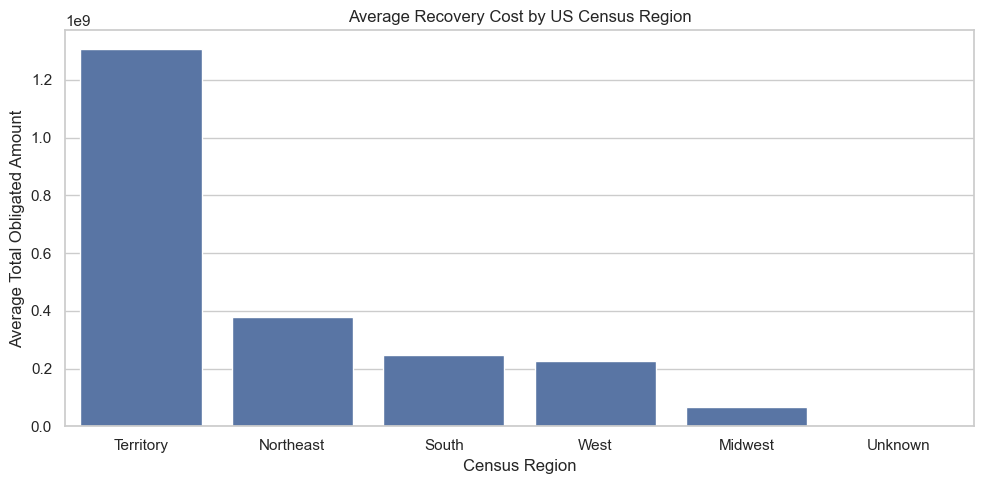

In [34]:
region_cost = (
    eda_df.groupby("census_region", as_index=False)["total_obligated_amount"]
    .mean()
    .sort_values("total_obligated_amount", ascending=False)
)

plt.figure(figsize=(10, 5))
sns.barplot(data=region_cost, x="census_region", y="total_obligated_amount")
plt.title("Average Recovery Cost by US Census Region")
plt.xlabel("Census Region")
plt.ylabel("Average Total Obligated Amount")
plt.tight_layout()
plt.show()

### Finding — Cost by Region

The analysis shows strong regional variation in average recovery cost, with territories having the highest average cost, followed by the Northeast, South, and West, while the Midwest shows significantly lower average costs.

This pattern suggests that:
- geographic location plays a significant role in disaster recovery cost
- certain regions are more exposed to high-impact disasters or more costly recovery conditions
- regional grouping captures meaningful variation beyond individual states

This reinforces the importance of including geographic features such as `state` or `census_region` in the modelling process.

## Section L — Temporal Trend in Average Recovery Cost

This section looks at how average disaster recovery cost changes over time.

Examining yearly patterns helps us understand whether disaster recovery costs appear to be:
- increasing over time
- fluctuating significantly
- influenced by major extreme events in specific years

Time-related patterns may later justify including year-based features in the model.

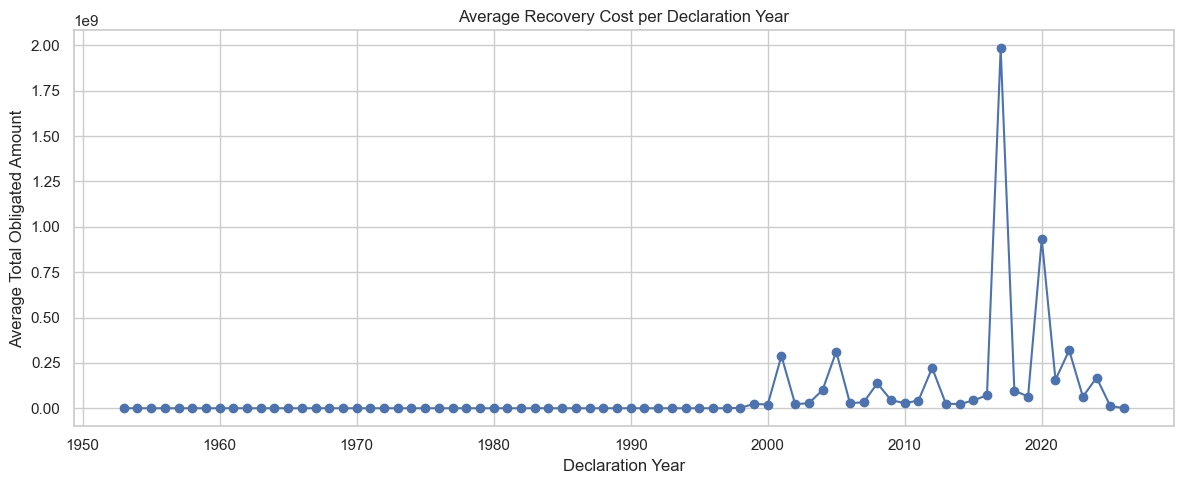

In [35]:
year_cost = (
    eda_df.groupby("declaration_year", as_index=False)["total_obligated_amount"]
    .mean()
    .dropna()
    .sort_values("declaration_year")
)

plt.figure(figsize=(12, 5))
plt.plot(year_cost["declaration_year"], year_cost["total_obligated_amount"], marker="o")
plt.title("Average Recovery Cost per Declaration Year")
plt.xlabel("Declaration Year")
plt.ylabel("Average Total Obligated Amount")
plt.tight_layout()
plt.show()

### Finding — Temporal Trend

The temporal trend shows that average disaster recovery cost has generally increased over time, with significant spikes in specific years (notably around 2017 and 2020).

These spikes likely correspond to major disaster events that significantly increased average costs in those years.

This indicates:
- disaster cost is influenced by rare but high-impact events
- time-based features may capture structural changes in disaster patterns or reporting
- models should account for temporal variation and potential non-stationarity in the data

## Section M — Seasonality in Recovery Cost by Declaration Month

Many disasters are seasonal. For example, hurricanes, storms, floods, and wildfires often have stronger patterns during certain times of the year.

This section uses a box plot to examine whether the cost distribution changes by declaration month.

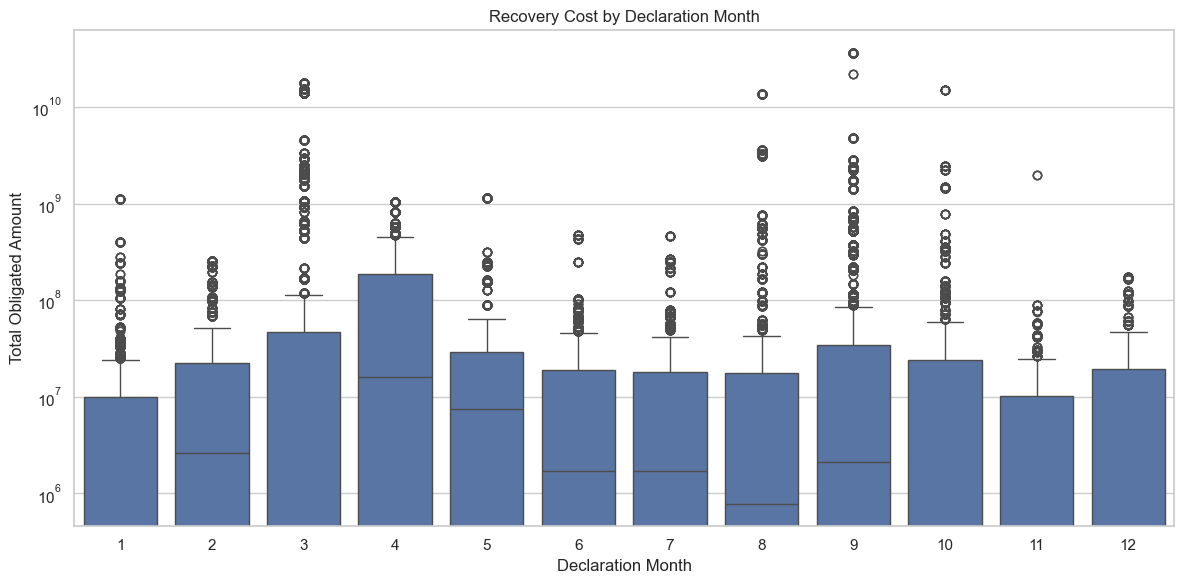

In [36]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=eda_df, x="declaration_month", y="total_obligated_amount")
plt.title("Recovery Cost by Declaration Month")
plt.xlabel("Declaration Month")
plt.ylabel("Total Obligated Amount")
plt.yscale("log")
plt.tight_layout()
plt.show()

### Finding — Seasonality

The box plot shows variation in recovery cost across months, with certain months (particularly late summer and early autumn) exhibiting higher variability and more extreme values.

This suggests:
- disaster costs are not evenly distributed throughout the year
- seasonal patterns likely reflect the timing of specific disaster types such as hurricanes and storms
- declaration month may serve as a useful feature for capturing seasonal risk patterns

## Section N — Correlation Heatmap of Numeric Features

This section explores relationships among the main numeric variables.

A correlation heatmap helps us understand:
- which numeric features move together
- whether any variables show linear association with the target
- whether there are signs of redundancy between engineered features

This is only an early signal. Low correlation does not mean a variable is useless, especially if the final model captures non-linear patterns.

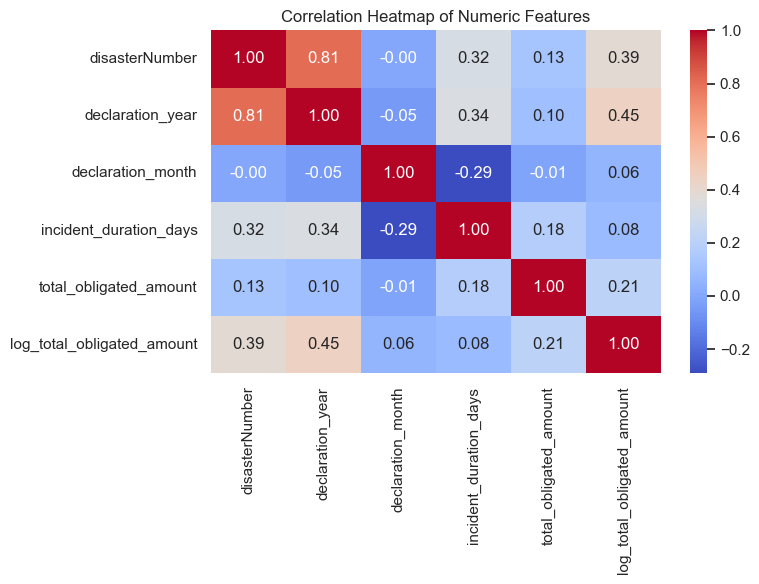

In [37]:
numeric_cols = [
    "disasterNumber",
    "declaration_year",
    "declaration_month",
    "incident_duration_days",
    "total_obligated_amount",
    "log_total_obligated_amount"
]

numeric_cols = [col for col in numeric_cols if col in eda_df.columns]

corr_df = eda_df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

### Finding — Correlation Structure

The correlation heatmap shows generally weak linear relationships between most numeric features and the target variable.

The strongest relationships observed are:
- a moderate correlation between `log_total_obligated_amount` and `declaration_year`
- a weak positive relationship between incident duration and total cost

This suggests:
- recovery cost is not strongly driven by simple linear relationships
- categorical features such as incident type and geography are likely more important than numeric features alone
- non-linear models may be better suited for capturing the underlying patterns in the data

## Section O — Outlier Detection on the Target Variable

Because disaster recovery cost is expected to be highly skewed, it is important to identify extreme values.

In this section, we use the IQR method to flag unusually high-cost disasters. These outliers are not automatically errors. In fact, they may represent the most important disasters from a business perspective.

The goal is to understand their scale and prepare for modelling decisions later.

In [39]:
Q1 = eda_df["total_obligated_amount"].quantile(0.25)
Q3 = eda_df["total_obligated_amount"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = eda_df[eda_df["total_obligated_amount"] > upper_bound]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper bound:", upper_bound)
print("Number of high-end outliers:", len(outliers))

Q1: 0.0
Q3: 27306108.25
IQR: 27306108.25
Upper bound: 68265270.625
Number of high-end outliers: 11071


In [40]:
outlier_cols = ["disasterNumber", "state", "incidentType", "declarationDate", "total_obligated_amount"]
outlier_cols = [col for col in outlier_cols if col in outliers.columns]

display(outliers[outlier_cols].head(20))

,disasterNumber,state,incidentType,declarationDate,total_obligated_amount
613,4798,TX,Hurricane,2024-07-09 00:00:00+00:00,2.516100e+08
614,4798,TX,Hurricane,2024-07-09 00:00:00+00:00,2.516100e+08
615,4798,TX,Hurricane,2024-07-09 00:00:00+00:00,2.516100e+08
616,4798,TX,Hurricane,2024-07-09 00:00:00+00:00,2.516100e+08
617,4798,TX,Hurricane,2024-07-09 00:00:00+00:00,2.516100e+08
618,4798,TX,Hurricane,2024-07-09 00:00:00+00:00,2.516100e+08
619,4798,TX,Hurricane,2024-07-09 00:00:00+00:00,2.516100e+08
620,4798,TX,Hurricane,2024-07-09 00:00:00+00:00,2.516100e+08
621,4798,TX,Hurricane,2024-07-09 00:00:00+00:00,2.516100e+08
622,4798,TX,Hurricane,2024-07-09 00:00:00+00:00,2.516100e+08


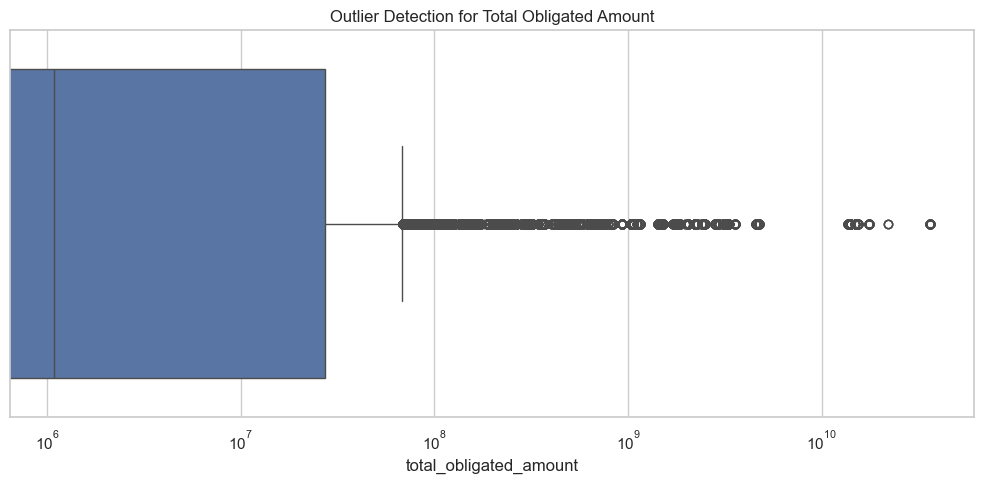

In [41]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=eda_df["total_obligated_amount"])
plt.title("Outlier Detection for Total Obligated Amount")
plt.xscale("log")
plt.tight_layout()
plt.show()

### Finding — Outliers

The box plot confirms the presence of extreme high-value outliers in disaster recovery cost, with several disasters reaching orders of magnitude higher than the majority.

These outliers are not errors but represent real catastrophic events.

This implies:
- extreme values are central to the problem and should not be removed blindly
- modelling approaches must be robust to heavy-tailed distributions
- evaluation metrics should account for large errors on high-cost disasters

## Section P — Early Hypotheses on Predictive Features

Based on the exploratory analysis, the following features appear most promising for predicting disaster recovery cost:

### Strong candidates
- `incidentType` → clear differences in average cost across disaster categories
- `state` / `census_region` → strong geographic variation in recovery cost
- `declaration_year` → evidence of temporal trends and major cost spikes
- `declaration_month` → indication of seasonal patterns
- `incident_duration_days` → weak but positive relationship with cost

### Important modelling considerations
- the target variable is highly skewed and zero-inflated
- extreme high-cost disasters drive a large portion of total variance
- linear relationships are weak, suggesting that non-linear models may perform better

### Additional feature opportunities for later stages
- historical disaster frequency by state
- rolling average cost per incident type
- interaction features (e.g., region × incident type)
- external enrichment features such as climate or socioeconomic indicators

These insights will guide feature engineering and model selection in the next stages of the project.

## EDA Summary

In this exploratory analysis, I combined three FEMA datasets to construct a disaster-level analytical dataset and defined the target variable `total_obligated_amount` by aggregating project-level public assistance funding.

The analysis revealed that disaster recovery cost is highly skewed and exhibits a zero-inflated distribution, with many disasters having no recorded cost and a small number of events accounting for extremely large expenditures. Applying a log transformation significantly improved the interpretability of the target distribution.

Significant variation in recovery cost was observed across incident types and geographic regions, indicating that disaster category and location are key drivers of cost. Temporal analysis showed an increasing trend in average recovery cost over time, with notable spikes corresponding to major disaster events. Seasonal patterns were also identified, suggesting that certain months are associated with higher variability in disaster cost.

Correlation analysis indicated weak linear relationships between numeric features and the target, reinforcing the importance of categorical and non-linear modelling approaches. Outlier analysis confirmed that extreme high-cost disasters are a fundamental part of the dataset and must be carefully handled in modelling.

Overall, the EDA highlights that disaster recovery cost is driven by a combination of incident type, geography, and temporal factors, and that modelling approaches must account for skewness, non-linearity, and extreme values to produce reliable predictions.